## 1장 2강: 데이터 분석 기초

### 2. 탐색적 데이터 분석(EDA, Exploratory Data Analysis)과 결측치/이상치

### 4. 타이타닉(Titanic) 탑승객 데이터 분석
#### 4.1 데이터 로드 및 결측치, 이상치 처리

타이타닉(Titanic) 탑승객 데이터 로드 하기

- df.head(): 앞쪽 5개 조회
- df.tail(): 뒤쪽 5개 조회

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

#df.iloc[:5]
#df[:5]
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


데이터 요약 및 통계 확인 하기

In [44]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


결측치 파악하기

In [45]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

숫자형 데이터(나이): 전체 탑승객의 '평균(mean)'으로 빈칸 채우기

In [46]:
mean_age = df['age'].mean()
print("평균 나이:", mean_age)

df['age'] = df['age'].fillna(mean_age)

df.isna().sum()

평균 나이: 29.69911764705882


survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

문자/범주형 데이터(탑승 항구): 가장 많이 탑승한 곳인 '최빈값(mode)'으로 빈칸 채우기

In [47]:
mode_embarked = df['embark_town'].mode()[0]

mode_embarked

'Southampton'

In [48]:
df['embark_town'] = df['embark_town'].fillna(mode_embarked)
df['embarked'] = df['embark_town'].map(lambda x: x[0].upper())

df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
dtype: int64

특정 컬럼(deck) 을 '기준'으로 좌우(열 방향) 데이터를 채우기

In [49]:
df['deck'] = df['deck'].ffill()
df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           1
embark_town    0
alive          0
alone          0
dtype: int64

In [50]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,C,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,C,Southampton,no,True


너무 비싼 요금(이상치) 걸러내기

In [51]:
import matplotlib.pyplot as plt

요금 평균: 32.204207968574636
중앙값: 14.4542


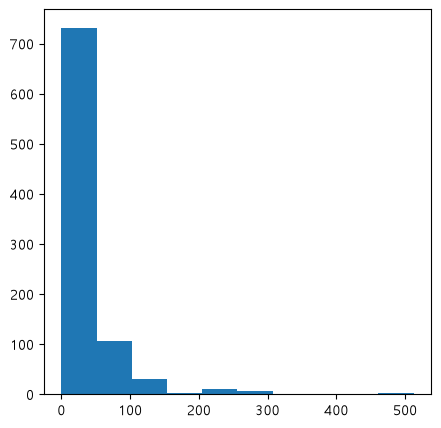

In [52]:
print("요금 평균:", df['fare'].mean())
print("중앙값:", df['fare'].median())

plt.figure(figsize=(5,5))
plt.hist(df['fare'], bins=10)
plt.show()

결측치/이상치 보완 결과 확인

#### 4.2 중복 데이터 처리하기

중복 데이터 확인하기

- duplicated() : 중복 행을 확인

In [53]:
df.duplicated().sum()

np.int64(39)

중복 데이터 제거하기

drop_duplicates() : 중복 행 삭제

In [54]:
#df.drop_duplicates()[:100]
df = df.drop_duplicates().reset_index(drop=True)

print("중복 데이터 수:", df.duplicated().sum())

중복 데이터 수: 0


#### 4.3 그래프로 시각화하기

내 컴퓨터에 맞는 한글 폰트 설정하기

In [55]:
import platform
from matplotlib import rc

os_name = platform.system()
if os_name == "Windows":
    rc("font", family="Malgun Gothic")
else:
    rc("font", family="Apple Gothic")

도화지(Figure)와 3개의 액자(Axes) 준비

C:\Users\sangh\AppData\Local\Temp\ipykernel_9884\1091785923.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='fare', data=df, ax=axes[1], palette='Set2')


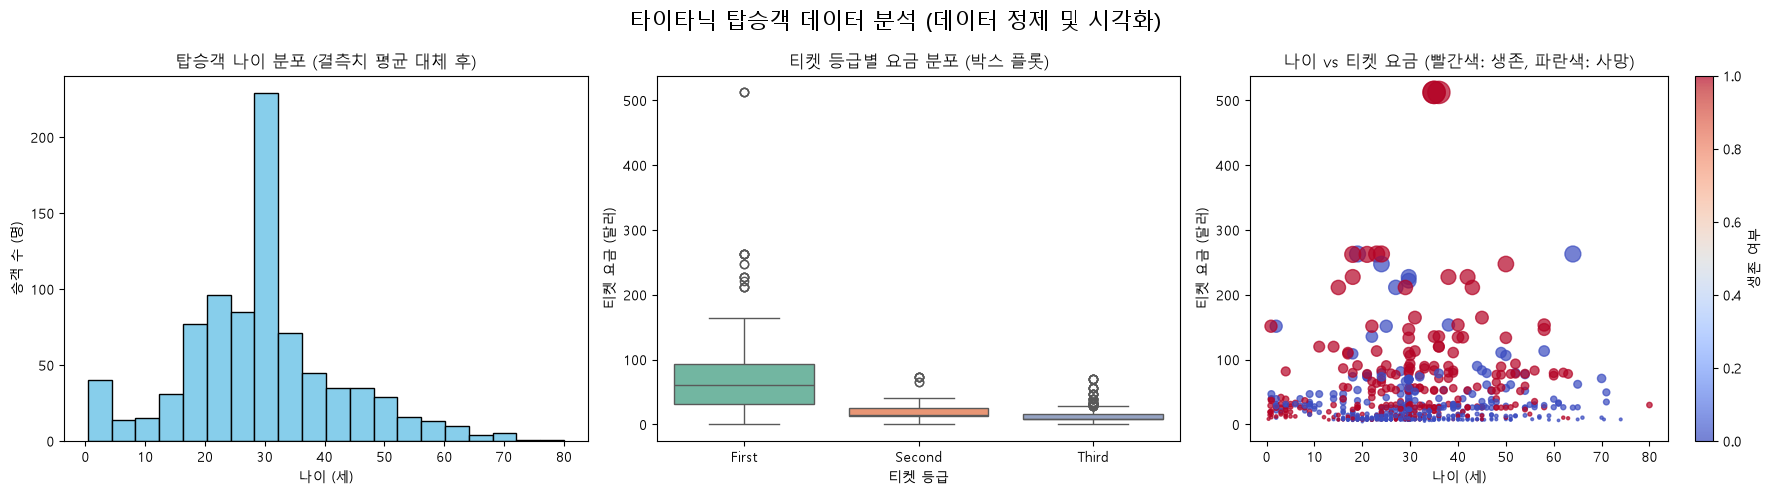

In [59]:
# 내 컴퓨터에 맞는 한글 폰트 설정하기
os_name = platform.system()
if os_name == "Windows":
    plt.rcParams['font.family'] = 'Malgun Gothic' # 윈도우
elif os_name == "Darwin":
    plt.rcParams['font.family'] = 'AppleGothic'   # 맥북
else:
    plt.rcParams['font.family'] = 'NanumGothic'   # 기타(코랩 등)

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 도화지(Figure)와 3개의 액자(Axes) 준비
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('타이타닉 탑승객 데이터 분석 (데이터 정제 및 시각화)', fontsize=16)

# [히스토그램] 탑승객 나이 분포
axes[0].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('탑승객 나이 분포 (결측치 평균 대체 후)')
axes[0].set_xlabel('나이 (세)')
axes[0].set_ylabel('승객 수 (명)')

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인
# 박스(상자) 바깥쪽에 외롭게 찍혀 있는 점들이 바로 일반적인 범위를 벗어난 '이상치'들입니다.
sns.boxplot(x='class', y='fare', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('티켓 등급별 요금 분포 (박스 플롯)')
axes[1].set_xlabel('티켓 등급')
axes[1].set_ylabel('티켓 요금 (달러)')

# [산점도] 나이와 클리닝된 요금의 관계
scatter = axes[2].scatter(
    df['age'], 
    df['fare'], 
    c=df['survived'], # 생존 여부(1: 생존, 0: 사망)에 따라 색상이 다름
    cmap='coolwarm',
    s=df['fare'] / 2, # 요금이 비쌀수록 원이 조금 더 큼
    alpha=0.7
)
axes[2].set_title('나이 vs 티켓 요금 (빨간색: 생존, 파란색: 사망)')
axes[2].set_xlabel('나이 (세)')
axes[2].set_ylabel('티켓 요금 (달러)')

fig.colorbar(scatter, ax=axes[2], label='생존 여부')

plt.tight_layout()
plt.show()

그래프로 분석하기

In [ ]:
# [히스토그램] 탑승객 나이 분포

# [박스 플롯] 티켓 등급에 따른 요금 이상치 확인

# [산점도] 나이와 클리닝된 요금의 관계